In [1]:
from dotenv import load_dotenv, find_dotenv

assert load_dotenv(find_dotenv(usecwd=False)), "The .env file was not loaded."

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import torch
from drn import *
import json
import os

from drn import split_and_preprocess
from analysis_utils import (
    rank_models_per_seed,
    get_nll_crps_rmse_ql,
    remove_duplicates_keep_one,
)

In [2]:
from train_new import train
from glm_new import *

In [3]:
# Read the CSV file into a DataFrame
csv_file_path = "data/freMPL1.csv"
df = pd.read_csv(csv_file_path)
claims = df.loc[df["ClaimAmount"] > 0, :]

In [4]:
# Scaling
target = claims["ClaimAmount"] / 1000
features = claims.drop("ClaimAmount", axis=1)
features = features.drop(
    ["RecordBeg", "RecordEnd", "ClaimInd", "Garage"], axis=1
)  # Drop garage due to missing values

print(features.shape)
# ADDITION
features, target, _, _ = remove_duplicates_keep_one(features, target)
print(features.shape)

# Check for duplicates in cleaned data
duplicates_exist = features.duplicated().any()

# Return whether duplicates exist
print(duplicates_exist)

# Convert "VehAge" categories to numeric
features["VehAge"] = features["VehAge"].map(
    {"0": 0, "1": 1, "2": 2, "3": 3, "4": 4, "5": 5, "6-7": 6, "8-9": 8, "10+": 11}
)
feature_names = features.columns

speed_ranges = [speed for speed in np.unique(features["VehMaxSpeed"])]
speed_series = pd.Series(speed_ranges)
mapping = {speed_range: i + 1 for i, speed_range in enumerate(speed_ranges)}
features["VehMaxSpeed"] = features["VehMaxSpeed"].map(mapping)
features["SocioCateg"] = features["SocioCateg"].str.extract("(\d+)").astype(int)

cat_features = [
    "HasKmLimit",
    "Gender",
    "MariStat",
    "VehUsage",
    "VehBody",
    "VehPrice",
    "VehEngine",
    "VehEnergy",
    "VehClass",
    "SocioCateg",
]

num_features = [feature for feature in features.columns if feature not in cat_features]

(3265, 17)
(2205, 17)
False


In [5]:
training = False

In [6]:
glm_gamma_dict_nll = {"1000": [], "3000": [], "6000": [], "20000": []}
glm_gamma_dict_crps = {"1000": [], "3000": [], "6000": [], "20000": []}
glm_gamma_dict_rmse = {"1000": [], "3000": [], "6000": [], "20000": []}
glm_gamma_dict_ql90 = {"1000": [], "3000": [], "6000": [], "20000": []}

drn_gamma_dict_nll = {"1000": [], "3000": [], "6000": [], "20000": []}
mdn_dict_nll = {"1000": [], "3000": [], "6000": [], "20000": []}
ddr_dict_nll = {"1000": [], "3000": [], "6000": [], "20000": []}

drn_gamma_dict_crps = {"1000": [], "3000": [], "6000": [], "20000": []}
mdn_dict_crps = {"1000": [], "3000": [], "6000": [], "20000": []}
ddr_dict_crps = {"1000": [], "3000": [], "6000": [], "20000": []}

drn_gamma_dict_rmse = {"1000": [], "3000": [], "6000": [], "20000": []}
mdn_dict_rmse = {"1000": [], "3000": [], "6000": [], "20000": []}
ddr_dict_rmse = {"1000": [], "3000": [], "6000": [], "20000": []}

drn_gamma_dict_ql90 = {"1000": [], "3000": [], "6000": [], "20000": []}
mdn_dict_ql90 = {"1000": [], "3000": [], "6000": [], "20000": []}
ddr_dict_ql90 = {"1000": [], "3000": [], "6000": [], "20000": []}

ddr_raw_dict_nll = {"1000": [], "3000": [], "6000": [], "20000": []}
ddr_raw_dict_crps = {"1000": [], "3000": [], "6000": [], "20000": []}
ddr_raw_dict_rmse = {"1000": [], "3000": [], "6000": [], "20000": []}
ddr_raw_dict_ql90 = {"1000": [], "3000": [], "6000": [], "20000": []}

cann_gamma_dict_nll = {"1000": [], "3000": [], "6000": [], "20000": []}
cann_gamma_dict_crps = {"1000": [], "3000": [], "6000": [], "20000": []}
cann_gamma_dict_rmse = {"1000": [], "3000": [], "6000": [], "20000": []}
cann_gamma_dict_ql90 = {"1000": [], "3000": [], "6000": [], "20000": []}

if not training:
    # # Define the folder path
    folder_path = "models/real/more_runs"  # Change this to your desired directory
    os.makedirs(folder_path, exist_ok=True)  # Create the directory if it doesn't exist

    # Define the file path
    file_path = os.path.join(folder_path, "more_runs.json")

    # Load the dictionary back from the file
    with open(file_path, "r") as f:
        loaded_dicts = json.load(f)

    # Dynamically assign all loaded dictionaries as variables
    globals().update(loaded_dicts)

    print("✅ All dictionaries successfully loaded!")

✅ All dictionaries successfully loaded!


# Training

In [7]:
distribution = "gamma"
for size, seed_num in zip([1000] * 100, [i for i in range(100) for _ in range(1)]):
    if training:
        proportion = 0.25
        hidden_size = 256
        dropout_rate = 0.2
        num_hidden_layers = 3
        lr = 1e-3
        batch_size = 128
        patience = 50
        kl_alpha = 5e-3

        print(f"Size: {size}; Seed: {seed_num}")
        print(
            "-----------------------------------------------------------------------------------"
        )

        # Split and preprocess the data
        (
            x_train,
            x_val,
            x_test,
            y_train,
            y_val,
            y_test,
            x_train_raw,
            x_val_raw,
            x_test_raw,
            num_features,
            cat_features,
            all_categories,
            ct,
        ) = split_and_preprocess(
            features, target, num_features, cat_features, seed=seed_num
        )

        X_train = torch.Tensor(x_train.values)
        Y_train = torch.Tensor(y_train.values)
        X_val = torch.Tensor(x_val.values)
        Y_val = torch.Tensor(y_val.values)
        X_test = torch.Tensor(x_test.values)
        Y_test = torch.Tensor(y_test.values)

        train_dataset = torch.utils.data.TensorDataset(X_train, Y_train)
        val_dataset = torch.utils.data.TensorDataset(X_val, Y_val)

        torch.manual_seed(23)
        glm_gamma = GLM(X_train.shape[1], distribution=distribution)
        train(
            glm_gamma,
            (
                gaussian_deviance_loss
                if distribution == "gaussian"
                else gamma_deviance_loss
            ),
            train_dataset,
            val_dataset,
            log_interval=100,
            epochs=5000,
            lr=0.001,
            patience=100,
            batch_size=100,
        )
        glm_gamma.update_dispersion(X_train, Y_train)
        glm_gamma.eval()

        cutpoints_DRN = drn_cutpoints(
            c_0=(
                np.min(Y_train.detach().numpy()) * 1.05
                if np.min(Y_train.detach().numpy()) < 0
                else 0.0
            ),
            c_K=np.max(Y_train.detach().numpy()) * 1.05,
            p=proportion,
            y=Y_train.detach().numpy(),
            min_obs=3,
        )
        print(len(cutpoints_DRN))

        torch.manual_seed(23)
        drn_gamma = DRN(
            num_features=X_train.shape[1],
            cutpoints=cutpoints_DRN,
            glm=glm_gamma,
            hidden_size=hidden_size,
            num_hidden_layers=num_hidden_layers,
            baseline_start=False,
            dropout_rate=dropout_rate,
        )
        if True:
            torch.manual_seed(23)
            train(
                model=drn_gamma,
                criterion=lambda pred, y: drn_loss(
                    pred,
                    y,
                    kl_alpha=kl_alpha,
                    dv_alpha=5e-2,
                    mean_alpha=5e-2,
                    kind="jbce",
                    kl_direction="forwards",
                ),
                criterion_val=lambda pred, y: drn_loss(
                    pred, y, kl_alpha=0.0, kind="jbce"
                ),
                train_dataset=train_dataset,
                val_dataset=val_dataset,
                batch_size=batch_size,
                epochs=5000,
                patience=patience,
                lr=lr,
                print_details=True,
                log_interval=50,
            )
            drn_gamma.eval()

        cutpoints_DDR = drn_cutpoints(
            c_0=(
                np.min(Y_train.detach().numpy()) * 1.05
                if np.min(Y_train.detach().numpy()) < 0
                else 0.0
            ),
            c_K=np.max(Y_train.detach().numpy()) * 1.05,
            p=proportion,
            y=Y_train.detach().numpy(),
            min_obs=0,
        )
        print(len(cutpoints_DDR))

        torch.manual_seed(23)
        ddr = DDR(
            x_train.shape[1],
            cutpoints_DDR,
            num_hidden_layers=num_hidden_layers,
            hidden_size=hidden_size,
            dropout_rate=dropout_rate,
        )  # , glm = glm)
        if True:
            torch.manual_seed(23)
            train(
                ddr,
                ddr_loss,
                train_dataset=train_dataset,
                val_dataset=val_dataset,
                lr=lr,
                batch_size=batch_size,
                log_interval=50,
                patience=patience,
                epochs=5000,
            )
            ddr.eval()

        torch.manual_seed(23)
        mdn = MDN(
            X_train.shape[1],
            num_hidden_layers=num_hidden_layers,
            hidden_size=hidden_size,
            dropout_rate=dropout_rate,
            num_components=5,
            distribution=distribution,
        )

        if True:
            torch.manual_seed(23)
            train(
                mdn,
                gaussian_mdn_loss if distribution == "gaussian" else gamma_mdn_loss,
                train_dataset,
                val_dataset,
                lr=lr,
                batch_size=batch_size,
                epochs=5000,
                patience=patience,
                log_interval=50,
            )
            mdn.eval()

        torch.manual_seed(23)
        cann_gamma = CANN(
            glm_gamma,
            num_hidden_layers=num_hidden_layers,
            hidden_size=hidden_size,
            dropout_rate=dropout_rate,
        )

        if True:
            torch.manual_seed(23)
            train(
                cann_gamma,
                (
                    gaussian_deviance_loss
                    if distribution == "gaussian"
                    else gamma_deviance_loss
                ),
                train_dataset,
                val_dataset,
                epochs=5000,
                lr=lr,
                patience=patience,
                batch_size=batch_size,
                log_interval=50,
            )
            cann_gamma.update_dispersion(X_train, Y_train)
            cann_gamma.eval()

        nll_test_dict, crps_test_dict, rmse_test_dict, ql_90_test_dict = (
            get_nll_crps_rmse_ql(
                models=[drn_gamma, cann_gamma, mdn, ddr, glm_gamma],
                names=["DRN", "CANN", "MDN", "DDR", "GLM"],
                X_test_data=X_test,
                Y_test_data=Y_test,
                y_train=y_train,
            )
        )

        drn_gamma_dict_nll[f"{size}"].append(nll_test_dict["DRN"].item())
        drn_gamma_dict_crps[f"{size}"].append(crps_test_dict["DRN"].item())
        drn_gamma_dict_rmse[f"{size}"].append(rmse_test_dict["DRN"].item())
        drn_gamma_dict_ql90[f"{size}"].append(ql_90_test_dict["DRN"].item())

        cann_gamma_dict_nll[f"{size}"].append(nll_test_dict["CANN"].item())
        cann_gamma_dict_crps[f"{size}"].append(crps_test_dict["CANN"].item())
        cann_gamma_dict_rmse[f"{size}"].append(rmse_test_dict["CANN"].item())
        cann_gamma_dict_ql90[f"{size}"].append(ql_90_test_dict["CANN"].item())

        ddr_raw_dict_nll[f"{size}"].append(nll_test_dict["DDR"].item())
        ddr_raw_dict_crps[f"{size}"].append(crps_test_dict["DDR"].item())
        ddr_raw_dict_rmse[f"{size}"].append(rmse_test_dict["DDR"].item())
        ddr_raw_dict_ql90[f"{size}"].append(ql_90_test_dict["DDR"].item())

        mdn_dict_nll[f"{size}"].append(nll_test_dict["MDN"].item())
        mdn_dict_crps[f"{size}"].append(crps_test_dict["MDN"].item())
        mdn_dict_rmse[f"{size}"].append(rmse_test_dict["MDN"].item())
        mdn_dict_ql90[f"{size}"].append(ql_90_test_dict["MDN"].item())

        glm_gamma_dict_nll[f"{size}"].append(nll_test_dict["GLM"].item())
        glm_gamma_dict_crps[f"{size}"].append(crps_test_dict["GLM"].item())
        glm_gamma_dict_rmse[f"{size}"].append(rmse_test_dict["GLM"].item())
        glm_gamma_dict_ql90[f"{size}"].append(ql_90_test_dict["GLM"].item())

In [8]:
if training:
    # Combine all dictionaries
    data_dicts = {
        "glm_gamma_dict_nll": glm_gamma_dict_nll,
        "glm_gamma_dict_crps": glm_gamma_dict_crps,
        "glm_gamma_dict_rmse": glm_gamma_dict_rmse,
        "glm_gamma_dict_ql90": glm_gamma_dict_ql90,
        "drn_gamma_dict_nll": drn_gamma_dict_nll,
        "mdn_dict_nll": mdn_dict_nll,
        "ddr_dict_nll": ddr_dict_nll,
        "drn_gamma_dict_crps": drn_gamma_dict_crps,
        "mdn_dict_crps": mdn_dict_crps,
        "ddr_dict_crps": ddr_dict_crps,
        "drn_gamma_dict_rmse": drn_gamma_dict_rmse,
        "mdn_dict_rmse": mdn_dict_rmse,
        "ddr_dict_rmse": ddr_dict_rmse,
        "drn_gamma_dict_ql90": drn_gamma_dict_ql90,
        "mdn_dict_ql90": mdn_dict_ql90,
        "ddr_dict_ql90": ddr_dict_ql90,
        "ddr_raw_dict_nll": ddr_raw_dict_nll,
        "ddr_raw_dict_crps": ddr_raw_dict_crps,
        "ddr_raw_dict_rmse": ddr_raw_dict_rmse,
        "ddr_raw_dict_ql90": ddr_raw_dict_ql90,
        "cann_gamma_dict_nll": cann_gamma_dict_nll,
        "cann_gamma_dict_crps": cann_gamma_dict_crps,
        "cann_gamma_dict_rmse": cann_gamma_dict_rmse,
        "cann_gamma_dict_ql90": cann_gamma_dict_ql90,
    }

    # Save the data
    folder_path = "models/real/more_runs"
    os.makedirs(folder_path, exist_ok=True)
    file_path = os.path.join(folder_path, "more_runs.json")

    with open(file_path, "w") as f:
        json.dump(data_dicts, f, indent=4)

    print(file_path)  # Show where it was saved

# Visualisation

In [9]:
# Dicts for each metric
metric_dicts_nll = {
    "DRN": drn_gamma_dict_nll,
    "CANN": cann_gamma_dict_nll,
    "MDN": mdn_dict_nll,
    "DDR": ddr_raw_dict_nll,
    "GLM": glm_gamma_dict_nll,
}

metric_dicts_crps = {
    "DRN": drn_gamma_dict_crps,
    "CANN": cann_gamma_dict_crps,
    "MDN": mdn_dict_crps,
    "DDR": ddr_raw_dict_crps,
    "GLM": glm_gamma_dict_crps,
}

metric_dicts_rmse = {
    "DRN": drn_gamma_dict_rmse,
    "CANN": cann_gamma_dict_rmse,
    "MDN": mdn_dict_rmse,
    "DDR": ddr_raw_dict_rmse,
    "GLM": glm_gamma_dict_rmse,
}

metric_dicts_ql90 = {
    "DRN": drn_gamma_dict_ql90,
    "CANN": cann_gamma_dict_ql90,
    "MDN": mdn_dict_ql90,
    "DDR": ddr_raw_dict_ql90,
    "GLM": glm_gamma_dict_ql90,
}

# List of models
models = ["GLM", "CANN", "MDN", "DDR", "DRN"]

# Get rankings for size = 1000 (change if needed)
ranks_nll = rank_models_per_seed(metric_dicts_nll, "nll", models)
ranks_crps = rank_models_per_seed(metric_dicts_crps, "crps", models)
ranks_rmse = rank_models_per_seed(metric_dicts_rmse, "rmse", models)
ranks_ql90 = rank_models_per_seed(metric_dicts_ql90, "ql90", models)


# Redefine the metric_ranks dictionary from the earlier context
metric_ranks = {
    "NLL": ranks_nll,
    "CRPS": ranks_crps,
    "RMSE": ranks_rmse,
    "QL90": ranks_ql90,
}


===== Ranks for NLL =====


,GLM,CANN,MDN,DDR,DRN
0,4.0,3.0,1.0,5.0,2.0
1,4.0,3.0,2.0,5.0,1.0
2,4.0,3.0,2.0,5.0,1.0
3,5.0,4.0,1.0,3.0,2.0
4,5.0,4.0,2.0,1.0,3.0
...,...,...,...,...,...
95,5.0,3.0,1.0,4.0,2.0
96,4.0,3.0,1.0,5.0,2.0
97,4.0,3.0,1.0,5.0,2.0
98,5.0,4.0,2.0,3.0,1.0



===== Ranks for CRPS =====


,GLM,CANN,MDN,DDR,DRN
0,4.0,3.0,2.0,5.0,1.0
1,5.0,4.0,2.0,3.0,1.0
2,4.0,3.0,2.0,5.0,1.0
3,5.0,4.0,2.0,3.0,1.0
4,5.0,4.0,2.0,3.0,1.0
...,...,...,...,...,...
95,5.0,3.0,1.0,4.0,2.0
96,5.0,4.0,1.0,3.0,2.0
97,5.0,4.0,1.0,3.0,2.0
98,5.0,4.0,2.0,3.0,1.0



===== Ranks for RMSE =====


,GLM,CANN,MDN,DDR,DRN
0,1.0,3.0,4.0,5.0,2.0
1,3.0,2.0,5.0,4.0,1.0
2,3.0,1.0,4.0,5.0,2.0
3,1.0,4.0,3.0,5.0,2.0
4,2.0,4.0,1.0,5.0,3.0
...,...,...,...,...,...
95,4.0,2.0,1.0,5.0,3.0
96,2.0,4.0,1.0,5.0,3.0
97,3.0,1.0,2.0,4.0,5.0
98,3.0,2.0,4.0,5.0,1.0



===== Ranks for QL90 =====


,GLM,CANN,MDN,DDR,DRN
0,3.0,4.0,2.0,5.0,1.0
1,5.0,4.0,2.0,3.0,1.0
2,3.0,4.0,2.0,5.0,1.0
3,1.0,5.0,3.0,4.0,2.0
4,5.0,4.0,2.0,3.0,1.0
...,...,...,...,...,...
95,5.0,3.0,1.0,4.0,2.0
96,4.0,5.0,1.0,3.0,2.0
97,1.0,3.0,2.0,5.0,4.0
98,1.0,2.0,4.0,5.0,3.0


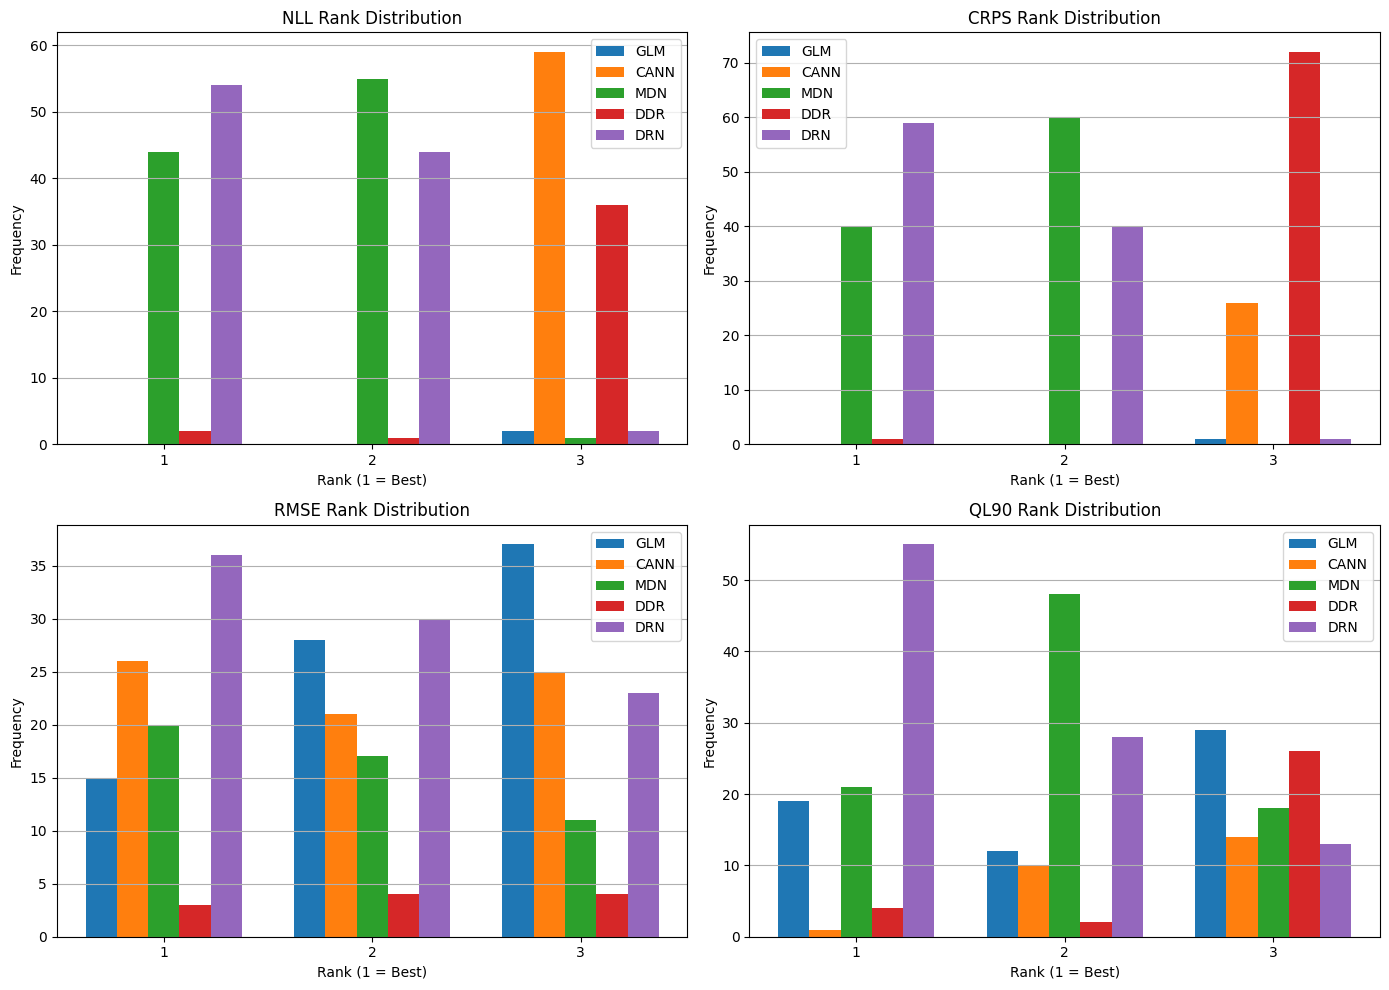

In [10]:
# Plotting side-by-side histograms at each x-tick (bar plot style)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

rank_bins = [1, 2, 3]  # 4, 5]
bar_width = 0.15
model_list = list(ranks_nll.columns)
x = np.arange(len(rank_bins))

for ax, (metric, rank_df) in zip(axes, metric_ranks.items()):
    for i, model in enumerate(model_list):
        counts = (
            rank_df[model].value_counts().reindex(rank_bins, fill_value=0).sort_index()
        )
        ax.bar(x + i * bar_width, counts.values, width=bar_width, label=model)

    ax.set_title(f"{metric} Rank Distribution")
    ax.set_xlabel("Rank (1 = Best)")
    ax.set_ylabel("Frequency")
    ax.set_xticks(x + bar_width * 2)
    ax.set_xticklabels(rank_bins)
    ax.legend()
    ax.grid(True, axis="y")

plt.tight_layout()

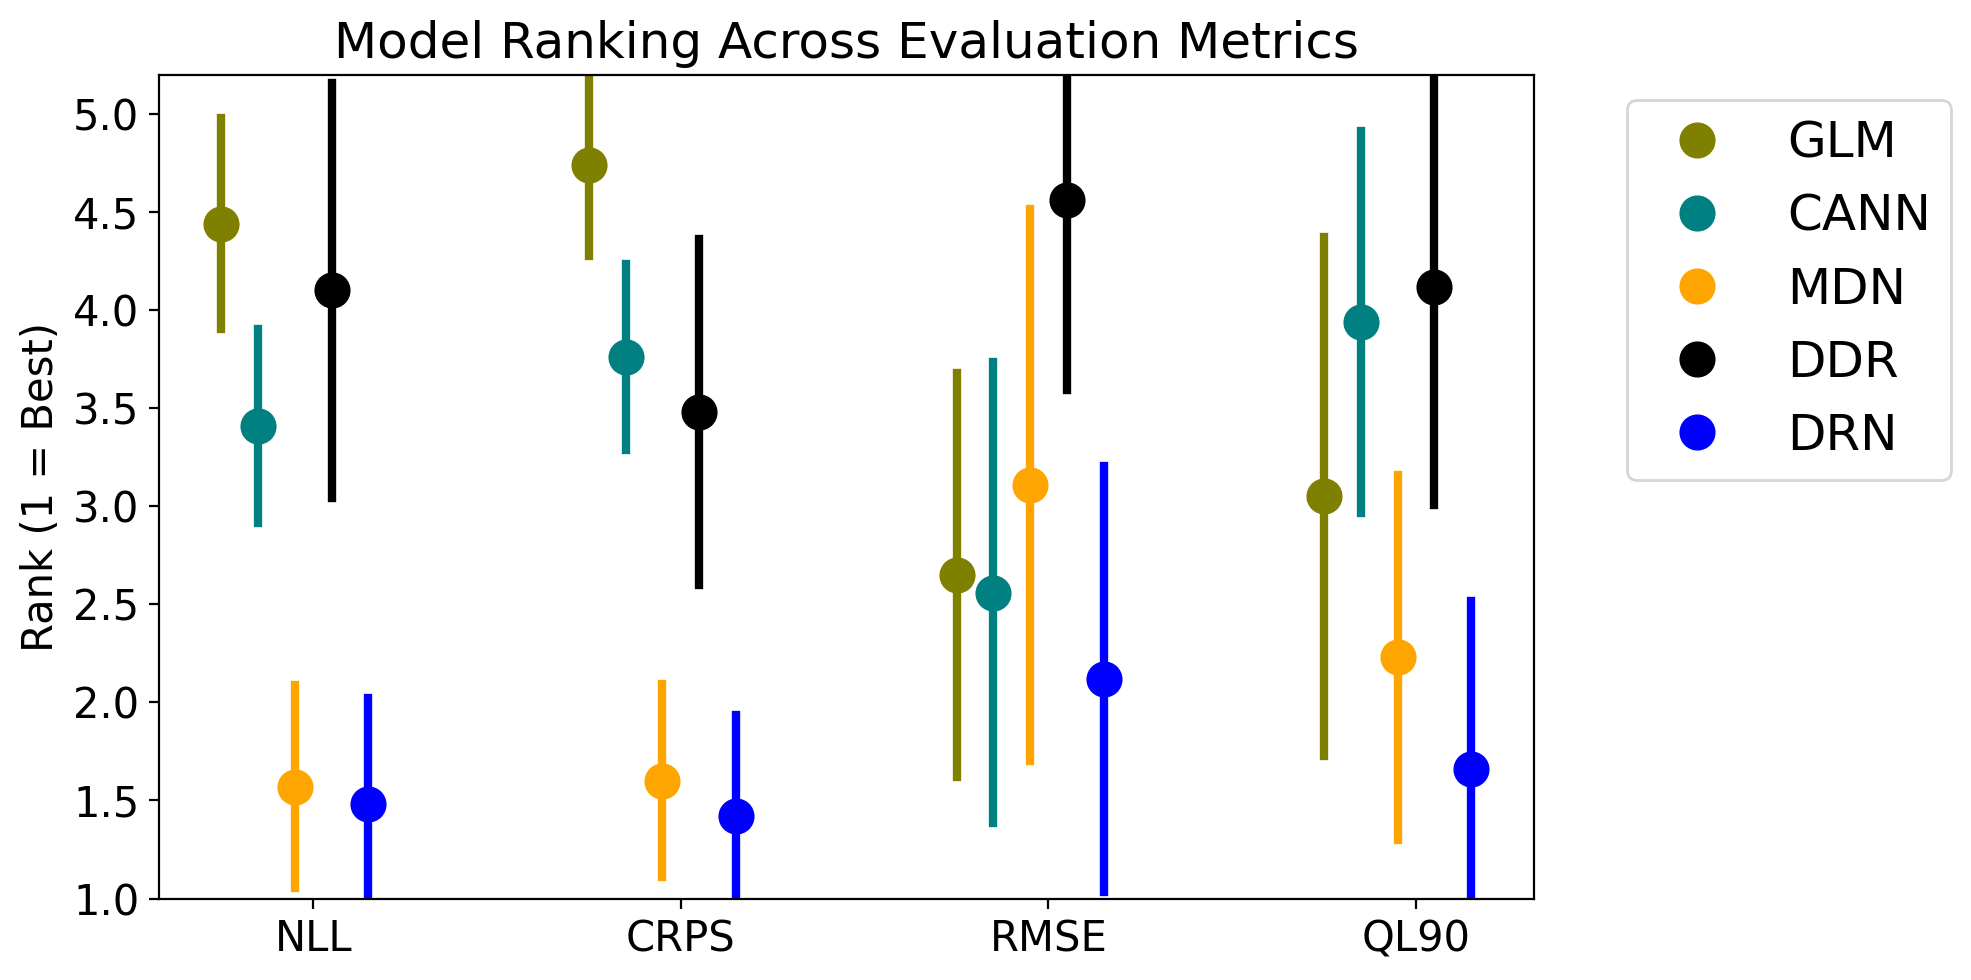

In [11]:
# Collect stats for all metrics
summary_stats = []

for metric_name, df in metric_ranks.items():
    for model in df.columns:
        summary_stats.append(
            {
                "Metric": metric_name,
                "Model": model,
                "Mean": df[model].mean(),
                "Std": df[model].std(),
            }
        )

summary_df = pd.DataFrame(summary_stats)

# Unique models and metrics for plotting
models = summary_df["Model"].unique()
metrics = summary_df["Metric"].unique()
metric_to_x = {metric: i for i, metric in enumerate(metrics)}
colors = dict(zip(models, sns.color_palette(n_colors=len(models))))

# Manually assign colors to each model
colors = {
    "DRN": "blue",  # blue
    "CANN": "teal",
    "MDN": "orange",  # orange
    "DDR": "black",  # red
    "GLM": "olive",
}

# Regenerate the plot with larger title and legend font sizes
plt.figure(figsize=(10, 5), dpi=200)  # High resolution

offset = 0.1  # horizontal spacing between model points
for i, metric in enumerate(metrics):
    for j, model in enumerate(models):
        row = summary_df[
            (summary_df["Metric"] == metric) & (summary_df["Model"] == model)
        ].iloc[0]
        x = i + (j - len(models) / 2) * offset
        color = colors[model]
        plt.plot(
            [x, x],
            [row["Mean"] - row["Std"], row["Mean"] + row["Std"]],
            color=color,
            linewidth=3,
        )
        plt.plot(x, row["Mean"], "o", color=color, label=model, markersize=12)

# Deduplicate legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(
    by_label.values(),
    by_label.keys(),
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=18,
)

plt.xticks(ticks=range(len(metrics)), labels=metrics, fontsize=15)
plt.yticks(fontsize=15)
plt.title("Model Ranking Across Evaluation Metrics", fontsize=18)
plt.ylabel("Rank (1 = Best)", fontsize=15)
plt.ylim(1, 5.2)
plt.tight_layout()
plt.show()